In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from math import*
import csv

In [2]:
data1 = pd.read_csv("Ca6Al7O16_dist_nm_FreeEnergy")
data2 = pd.read_csv("Ca23Al28O64_dist_nm_FreeEnergy")
data3 = pd.read_csv("Ca22Al28O64_dist_nm_FreeEnergy")

In [3]:
data1.to_csv('data6716_1st.csv', index= None)
data2.to_csv('data232864_3rd.csv', index= None)
data3.to_csv('data222864_2nd.csv', index= None)

In [4]:
df1 = pd.read_csv('data6716_1st.csv', header = None)
df2 = pd.read_csv('data232864_3rd.csv', header = None)
df3 = pd.read_csv('data222864_2nd.csv', header = None)

In [5]:
df1.rename(columns= {0 : 'd', 1: 'f'}, inplace= True)
df2.rename(columns= {0 : 'd', 1: 'f'}, inplace= True)
df3.rename(columns= {0 : 'd', 1: 'f'}, inplace= True)

In [6]:
import matplotlib.pyplot as plt
from pymatgen.util.plotting import pretty_plot
from monty.json import MSONable

class plot_properties(MSONable):
    def __init__(self, pltt, font_type='Open Sans', font_size='26', axis_ticks_font_size='22',label_x="", label_y="", lagend_size='24', xlimit=8, ylimit=6):
        self.font_size=font_size
        self.axis_ticks_font_size=axis_ticks_font_size        
        self.font_type = font_type
        self.label_x = label_x
        self.label_y =label_y
        self.lagend_size = lagend_size
        self.xlimit = xlimit
        self.ylimit = ylimit
        self.plt = pltt
    
    def get_plot_style(self):
        print('hello')
        ax = pretty_plot(self.xlimit, self.ylimit, self.plt)
        plt.axes(ax)
        
        axis_font = {'fontname':self.font_type, 'size':self.font_size, 'fontweight':'bold'}
        axis_ticks_font = {'fontname':self.font_type, 'size':self.axis_ticks_font_size, 'fontweight':'bold'}
        plt.rc('font',**{'family':[self.font_type], 'size':self.lagend_size, 'weight':'bold'}) 
        params = {'mathtext.default': 'regular' } 
        plt.rcParams.update(params) 
        plt.rcParams['mathtext.fontset'] = 'custom'
        plt.rcParams['mathtext.rm'] = self.font_type
        plt.rcParams['mathtext.it'] = self.font_type+ ':italic'#':italic'
        plt.rcParams['mathtext.bf'] = self.font_type+':bold'
        #plt.rcParams['boxplot.boxprops.linewidth'] = 20
        plt.ylabel(self.label_y, **axis_font)
        plt.xlabel(self.label_x,  **axis_font)
        plt.xticks(**axis_ticks_font)
        plt.yticks(**axis_ticks_font)
        ax=plt.gca()
        #ax = self.plt
        ax.get_yaxis().set_tick_params(direction='in', width=2, size=6, right='on')
        ax.get_xaxis().set_tick_params(direction='in', width=2, size=6, top='on')
        thickness=2
        ax.spines['top'].set_linewidth(thickness)
        ax.spines['right'].set_linewidth(thickness)
        ax.spines['left'].set_linewidth(thickness)
        ax.spines['bottom'].set_linewidth(thickness)
        #ax.get_xaxis().tick_bottom()   # remove unneeded ticks 
        #ax.get_yaxis().tick_left()
        #plt.tight_layout()
        return plt

def pp(pltt):
    return plot_properties(pltt=None, xlimit=8, ylimit=6,
                           lagend_size=14, axis_ticks_font_size=16,
                           font_size=216).get_plot_style()

findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family ['Open Sans'] not found. Falling back to DejaVu Sans.


hello


findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family ['Open Sans'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Open Sans'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Open Sans'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Open Sans'] not found. Falling back to DejaVu Sans.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family

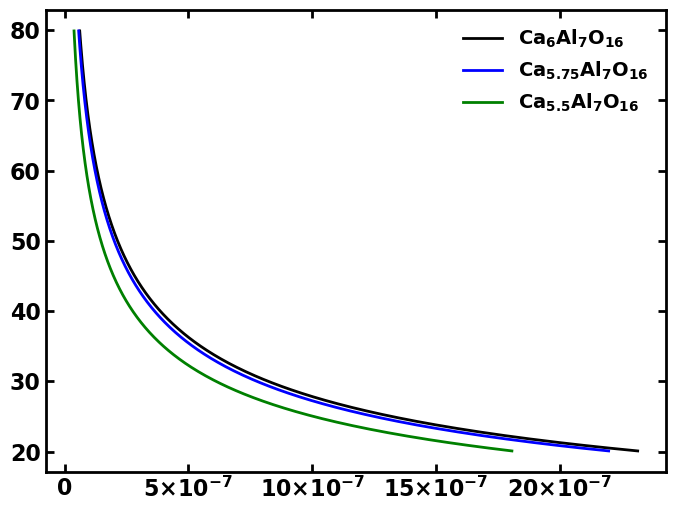

In [7]:
plt=pp(plt)
plt.plot(-df1['f'][200:799], df1['d'][200:799], 'k', lw = 2, alpha =1,label = '$Ca_{6}Al_{7}O_{16}$')

plt.plot(-df2['f'][200:799], df2['d'][200:799],'b' , lw = 2, alpha =1, label = '$Ca_{5.75}Al_{7}O_{16}$')
plt.plot(-df3['f'][200:799], df3['d'][200:799], 'g',lw = 2, alpha =1,label = '$Ca_{5.5}Al_{7}O_{16}$')

# plt.yscale("log")
plt.xticks([0.0*10**(-6), 0.5*10**(-6),1.0*10**(-6),1.5*10**(-6),2.0*10**(-6)],[r"0",r"5$\times$10$^{-7}$",r"10$\times$10$^{-7}$",r"15$\times$10$^{-7}$",r"20$\times$10$^{-7}$"])

plt.legend(frameon=False)
plt.savefig('d_vs_f_ca.png', bbox_inches= 'tight', dpi=1000)
plt.show()